# Three-class Medical-Oriented ROI + 2.5D Slice Classification

This notebook trains three condition-specific classifiers for lumbar spine degeneration using metadata, ROI cropping, and optional 2.5D neighbouring-slice input. The model architecture remains a 3-channel image backbone plus metadata embeddings; when 2.5D is enabled, the three channels correspond to previous/current/next slices instead of repeated grayscale.


## 1. Imports

In [1]:
# IMPORTS
import os
import re
import copy
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2
import pydicom
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import transforms, models

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    log_loss,
    roc_curve,
    auc,
    roc_auc_score,
)

from tqdm.auto import tqdm
from sklearn.preprocessing import label_binarize


## 2. Reproducibility and configuration

In [2]:
# SET SEED FOR REPRODUCIBILITY
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

set_seed(42)

In [3]:
# ----------------------------
# CONFIG
# ----------------------------
import os

ROOT = Path("/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification")
DATA_ROOT = Path("/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/BC-data")
PROJECT_ROOT = Path("/home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/Classification-baseline")
DATA_CSV = DATA_ROOT / "data-rsna2024" / "data_merged.csv"
os.chdir(ROOT)

# Output folder for trained models and results.
MODEL_ROOT_DIR = Path("models")
RUN_NAME = "models_baseline_three_class_medical_oriented_roi_crop_2p5d"

OUTPUT_DIR = MODEL_ROOT_DIR / RUN_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Transfer learning is recommended for this limited medical-imaging setup.
PRETRAINED = True

IMAGE_SIZE = 224
BATCH_SIZE = 32

# ROI cropping controls.
# The model architecture stays unchanged: the crop is resized to IMAGE_SIZE.
ROI_CROP_ENABLED = True
ROI_CROP_SIZE = 128        # square crop size in original DICOM pixels before resizing to IMAGE_SIZE
ROI_FALLBACK_TO_FULL_IMAGE = True
X_COLUMN = None            # inferred automatically after loading DATA_CSV
Y_COLUMN = None            # inferred automatically after loading DATA_CSV

# 2.5D slice-context controls.
# If enabled, the 3 input channels are [previous slice, current slice, next slice].
# If disabled, the input is the current grayscale image repeated into 3 channels.
USE_2_5D_INPUT = True
SLICE_CONTEXT_OFFSETS = (-1, 0, 1)
SERIES_GROUP_COLUMNS = None   # inferred automatically, usually ["study_id", "series_id"]
SLICE_ORDER_COLUMN = None     # inferred automatically, usually "instance_number"


# Early stopping is allowed only after MIN_EPOCHS.
# These values are less aggressive than recall-only stopping.
EPOCHS = 50
MIN_EPOCHS = 15
PATIENCE = 10
MIN_DELTA = 1e-4

LR = 1e-4
BACKBONE_LR_MULTIPLIER = 0.1
WEIGHT_DECAY = 1e-4

# DataLoader performance settings.
# Keep NUM_WORKERS > 0 for speed. persistent_workers reduces repeated worker cleanup.
NUM_WORKERS = 4
PIN_MEMORY = True
PERSISTENT_WORKERS = True
PREFETCH_FACTOR = 2

# Model-head regularization.
HIDDEN_DIM = 512
DROPOUT = 0.15

# Class imbalance and medical-priority controls.
# The base class weights are inverse-frequency weights from the training split.
# Moderate and severe classes can receive an extra multiplier because false negatives
# are more costly in this medical task, especially for severe cases.
MODERATE_WEIGHT_MULTIPLIER = 1.1
SEVERE_WEIGHT_MULTIPLIER = 1.3
USE_WEIGHTED_SAMPLER = False
LABEL_SMOOTHING = 0.0
GRAD_CLIP_NORM = 1.0

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def dataloader_worker_kwargs(num_workers=NUM_WORKERS):
    """Return DataLoader worker-related kwargs that are valid for the chosen num_workers."""
    kwargs = {
        "num_workers": num_workers,
        "pin_memory": PIN_MEMORY,
    }

    if num_workers > 0:
        kwargs["persistent_workers"] = PERSISTENT_WORKERS
        kwargs["prefetch_factor"] = PREFETCH_FACTOR

    return kwargs


print("Using device:", DEVICE)
print("Project root:", PROJECT_ROOT)
print("Data CSV:", DATA_CSV)
print("Output dir:", OUTPUT_DIR)
print("NUM_WORKERS:", NUM_WORKERS)
print("ROI crop enabled:", ROI_CROP_ENABLED)
print("2.5D input enabled:", USE_2_5D_INPUT)


Using device: cuda
Project root: /home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/Classification-baseline
Data CSV: /home/jupyter-lukj08@vse.cz/VSE_bachelor_thesis_lumbar_spine_degeneration_classification/BC-data/data-rsna2024/data_merged.csv
Output dir: models/models_baseline_three_class_medical_oriented_roi_crop_2p5d
NUM_WORKERS: 4
ROI crop enabled: True
2.5D input enabled: True


## 3. Load and prepare dataframe

This section creates:

- `base_condition`: condition without left/right prefix
- `side`: `center`, `left`, or `right`
- `target`: severity encoded as `0`, `1`, `2`

For the first full-image classifiers, coordinates `x` and `y` are not used.

In [4]:
# LABEL DEFINITIONS
data_merged = pd.read_csv(DATA_CSV)

SEVERITY_MAP = {
    "Normal/Mild": 0,
    "Moderate": 1,
    "Severe": 2,
}

TARGET_NAMES = ["Normal/Mild", "Moderate", "Severe"]
N_CLASSES = len(TARGET_NAMES)

LEVELS = ["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"]

SIDE_TO_ID = {
    "center": 0,
    "left": 1,
    "right": 2,
}

SERIES_TO_ID = {
    "Sagittal T2/STIR": 0,
    "Sagittal T1": 1,
    "Axial T2": 2,
}

LEVEL_TO_ID = {level: idx for idx, level in enumerate(LEVELS)}


def extract_side(condition):
    condition = str(condition).lower()

    if condition.startswith("left"):
        return "left"
    elif condition.startswith("right"):
        return "right"
    else:
        return "center"


def extract_base_condition(condition):
    condition = str(condition)
    return (
        condition
        .replace("Left ", "")
        .replace("Right ", "")
    )


def infer_coordinate_columns(df):
    """Infer coordinate columns used for ROI cropping."""
    x_candidates = ["x", "coord_x", "x_coord", "coordinate_x", "keypoint_x", "image_x"]
    y_candidates = ["y", "coord_y", "y_coord", "coordinate_y", "keypoint_y", "image_y"]

    x_col = next((col for col in x_candidates if col in df.columns), None)
    y_col = next((col for col in y_candidates if col in df.columns), None)

    return x_col, y_col


def infer_series_group_columns(df):
    """
    Infer columns that identify one DICOM series.

    Best case: study_id + series_id / series_instance_uid.
    Fallback: study_id + series_description. The fallback can mix repeated series
    of the same type within one study, so the detected columns are printed below.
    """
    series_candidates = [
        "series_id",
        "SeriesInstanceUID",
        "series_instance_uid",
        "series_uid",
    ]

    for series_col in series_candidates:
        if series_col in df.columns:
            return ["study_id", series_col]

    return ["study_id", "series_description"]


def infer_slice_order_column(df):
    """Infer column used to order slices within a series."""
    candidates = [
        "instance_number",
        "InstanceNumber",
        "instance",
        "slice_number",
        "slice_idx",
        "image_number",
        "image_index",
        "dicom_instance_number",
        "z",
    ]

    return next((col for col in candidates if col in df.columns), None)


def parse_slice_order_from_path(path):
    """
    Fallback ordering when no DICOM instance column exists.
    Extracts the final integer from the file stem/path.
    """
    matches = re.findall(r"\d+", str(path))
    if len(matches) == 0:
        return np.nan
    return int(matches[-1])


data_merged["side"] = data_merged["condition"].apply(extract_side)
data_merged["base_condition"] = data_merged["condition"].apply(extract_base_condition)
data_merged["target"] = data_merged["severity"].map(SEVERITY_MAP)

# Infer ROI coordinate columns.
if ROI_CROP_ENABLED:
    inferred_x_col, inferred_y_col = infer_coordinate_columns(data_merged)

    if X_COLUMN is None:
        X_COLUMN = inferred_x_col
    if Y_COLUMN is None:
        Y_COLUMN = inferred_y_col

    print("ROI cropping enabled:", ROI_CROP_ENABLED)
    print("ROI x column:", X_COLUMN)
    print("ROI y column:", Y_COLUMN)

    if X_COLUMN is None or Y_COLUMN is None:
        print("WARNING: Coordinate columns were not found. The dataset will fall back to full images.")
    else:
        data_merged[X_COLUMN] = pd.to_numeric(data_merged[X_COLUMN], errors="coerce")
        data_merged[Y_COLUMN] = pd.to_numeric(data_merged[Y_COLUMN], errors="coerce")

        missing_roi = data_merged[[X_COLUMN, Y_COLUMN]].isna().any(axis=1).sum()
        print(f"Rows with missing ROI coordinates: {missing_roi} / {len(data_merged)}")

# Infer 2.5D series grouping and slice ordering.
if USE_2_5D_INPUT:
    if SERIES_GROUP_COLUMNS is None:
        SERIES_GROUP_COLUMNS = infer_series_group_columns(data_merged)

    if SLICE_ORDER_COLUMN is None:
        SLICE_ORDER_COLUMN = infer_slice_order_column(data_merged)

    if SLICE_ORDER_COLUMN is None:
        SLICE_ORDER_COLUMN = "_slice_order_from_path"
        data_merged[SLICE_ORDER_COLUMN] = data_merged["img_path"].apply(parse_slice_order_from_path)

    print("2.5D input enabled:", USE_2_5D_INPUT)
    print("Series group columns:", SERIES_GROUP_COLUMNS)
    print("Slice order column:", SLICE_ORDER_COLUMN)

    if SERIES_GROUP_COLUMNS == ["study_id", "series_description"]:
        print(
            "WARNING: No explicit series_id column was found. "
            "Using study_id + series_description as a fallback for neighbouring slices."
        )


data_merged = data_merged.dropna(subset=[
    "study_id",
    "img_path",
    "target",
    "level",
    "side",
    "series_description",
]).copy()

if USE_2_5D_INPUT:
    data_merged[SLICE_ORDER_COLUMN] = pd.to_numeric(
        data_merged[SLICE_ORDER_COLUMN],
        errors="coerce",
    )

data_merged["target"] = data_merged["target"].astype(int)
print(data_merged["base_condition"].value_counts())
print("==========================")
print(data_merged["series_description"].value_counts())
#display(data_merged.head())


ROI cropping enabled: True
ROI x column: x
ROI y column: y
Rows with missing ROI coordinates: 0 / 48692
2.5D input enabled: True
Series group columns: ['study_id', 'series_id']
Slice order column: instance_number
base_condition
Neural Foraminal Narrowing    19689
Subarticular Stenosis         19215
Spinal Canal Stenosis          9753
Name: count, dtype: int64
series_description
Sagittal T1         19694
Axial T2            19215
Sagittal T2/STIR     9748
Name: count, dtype: int64


## 4. Study-level train/validation/test split
Split is created by `study_id`, which prevents patient/study leakage.

In [5]:
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15
RANDOM_STATE = 42

# First split: train vs temporary validation + test
gss1 = GroupShuffleSplit(
    n_splits=1,
    train_size=TRAIN_SIZE,
    random_state=RANDOM_STATE,
)

train_idx, temp_idx = next(
    gss1.split(
        data_merged,
        groups=data_merged["study_id"],
    )
)

train_df = data_merged.iloc[train_idx].copy()
temp_df = data_merged.iloc[temp_idx].copy()

# Second split: validation vs test from the temporary set
val_relative_size = VAL_SIZE / (VAL_SIZE + TEST_SIZE)

gss2 = GroupShuffleSplit(
    n_splits=1,
    train_size=val_relative_size,
    random_state=RANDOM_STATE,
)

val_idx, test_idx = next(
    gss2.split(
        temp_df,
        groups=temp_df["study_id"],
    )
)

val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

print("Rows:")
print("train:", train_df.shape)
print("val:  ", val_df.shape)
print("test: ", test_df.shape)

print("\nUnique studies:")
print("train:", train_df["study_id"].nunique())
print("val:  ", val_df["study_id"].nunique())
print("test: ", test_df["study_id"].nunique())

Rows:
train: (34045, 14)
val:   (7289, 14)
test:  (7323, 14)

Unique studies:
train: 1381
val:   296
test:  297


In [6]:
# Cell 1: prepare merged dataframe
plot_df = pd.concat(
    [
        train_df[["condition", "base_condition", "severity"]].assign(split="train"),
        val_df[["condition", "base_condition", "severity"]].assign(split="val"),
        test_df[["condition", "base_condition", "severity"]].assign(split="test"),
    ],
    ignore_index=True,
)

plot_df["condition_plot"] = plot_df["base_condition"]

plot_df.loc[
    plot_df["condition"].str.contains("Left Neural Foraminal Narrowing", na=False),
    "condition_plot"
] = "Left Neural Foraminal Narrowing"

plot_df.loc[
    plot_df["condition"].str.contains("Right Neural Foraminal Narrowing", na=False),
    "condition_plot"
] = "Right Neural Foraminal Narrowing"

severity_order = ["Normal/Mild", "Moderate", "Severe"]
split_order = ["train", "val", "test"]

plot_df["severity"] = pd.Categorical(plot_df["severity"], categories=severity_order, ordered=True)
plot_df["split"] = pd.Categorical(plot_df["split"], categories=split_order, ordered=True)

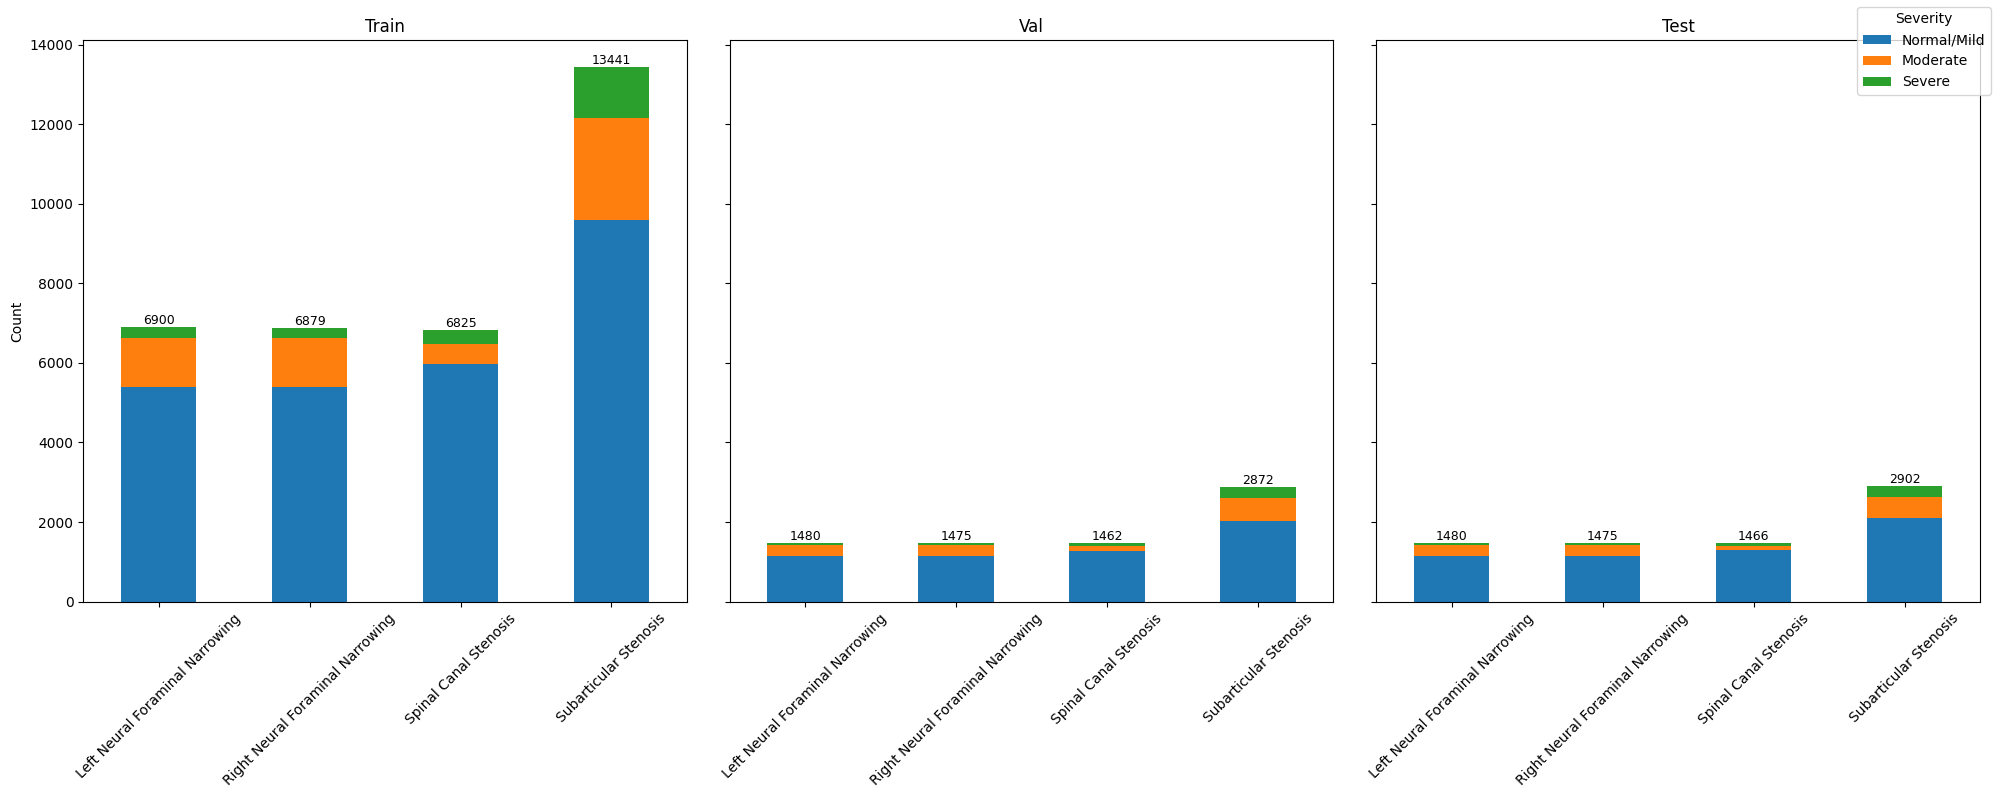

In [7]:
# Cell 2: side-by-side stacked bar charts with total counts

import matplotlib.pyplot as plt

condition_order = sorted(plot_df["condition_plot"].dropna().unique())

fig, axes = plt.subplots(1, 3, figsize=(20, 8), sharey=True)

for ax, split in zip(axes, split_order):
    split_counts = pd.crosstab(
        plot_df.loc[plot_df["split"] == split, "condition_plot"],
        plot_df.loc[plot_df["split"] == split, "severity"]
    ).reindex(index=condition_order, columns=severity_order, fill_value=0)

    split_counts.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        legend=False
    )

    totals = split_counts.sum(axis=1)

    for i, total in enumerate(totals):
        ax.text(
            i,
            total,
            str(int(total)),
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax.set_title(f"{split.capitalize()}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)

axes[0].set_ylabel("Count")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Severity", loc="upper right")

plt.tight_layout()
plt.show()

## 5. Define the three classifiers

Each model is trained on the matching sequence and condition.

In [8]:
MODEL_CONFIGS = {
    "spinal_canal_stenosis": {
        "base_condition": "Spinal Canal Stenosis",
        "series_description": "Sagittal T2/STIR",
    },
    "neural_foraminal_narrowing": {
        "base_condition": "Neural Foraminal Narrowing",
        "series_description": "Sagittal T1",
    },
    "subarticular_stenosis": {
        "base_condition": "Subarticular Stenosis",
        "series_description": "Axial T2",
    },
}


def make_model_df(df, base_condition, series_description):
    out = df[
        (df["base_condition"] == base_condition) &
        (df["series_description"] == series_description)
    ].copy()

    out = out.dropna(subset=[
        "img_path",
        "target",
        "level",
        "side",
        "series_description",
    ])

    return out.reset_index(drop=True)


model_dfs = {}

for model_name, cfg in MODEL_CONFIGS.items():
    model_dfs[model_name] = {
        "train": make_model_df(train_df, cfg["base_condition"], cfg["series_description"]),
        "val": make_model_df(val_df, cfg["base_condition"], cfg["series_description"]),
        "test": make_model_df(test_df, cfg["base_condition"], cfg["series_description"]),
    }

for model_name, parts in model_dfs.items():
    print("\n", model_name)
    for split_name, split_df in parts.items():
        print(f"{split_name:5s}: {len(split_df):6d} rows | {split_df['study_id'].nunique():4d} studies")
        print(split_df["target"].value_counts().sort_index().rename(index=dict(enumerate(TARGET_NAMES))))


 spinal_canal_stenosis
train:   6820 rows | 1380 studies
target
Normal/Mild    5964
Moderate        513
Severe          343
Name: count, dtype: int64
val  :   1462 rows |  296 studies
target
Normal/Mild    1282
Moderate        117
Severe           63
Name: count, dtype: int64
test :   1466 rows |  297 studies
target
Normal/Mild    1303
Moderate        101
Severe           62
Name: count, dtype: int64

 neural_foraminal_narrowing
train:  13779 rows | 1380 studies
target
Normal/Mild    10800
Moderate        2462
Severe           517
Name: count, dtype: int64
val  :   2955 rows |  296 studies
target
Normal/Mild    2280
Moderate        538
Severe          137
Name: count, dtype: int64
test :   2955 rows |  296 studies
target
Normal/Mild    2275
Moderate        559
Severe          121
Name: count, dtype: int64

 subarticular_stenosis
train:  13441 rows | 1381 studies
target
Normal/Mild    9601
Moderate       2549
Severe         1291
Name: count, dtype: int64
val  :   2872 rows |  296 studi

## 6. Create dataset

The default input is:

```text
DICOM grayscale → percentile clipping → [0, 1] normalization → PIL grayscale
```

Then transforms convert it to a 3-channel tensor by repeating grayscale values.

This dataset returns:

```text
image tensor, metadata dictionary, target label
```

For the first three classifiers, coordinates are intentionally not used.

In [9]:
def read_dicom_array(path, clip_percentiles=(1, 99)):
    """Read one DICOM image and return a normalized float32 grayscale array in [0, 1]."""
    ds = pydicom.dcmread(path)

    img = ds.pixel_array.astype(np.float32)

    # Correct display inversion for MONOCHROME1.
    if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
        img = img.max() - img

    # Robust clipping reduces the influence of extreme values.
    low, high = np.percentile(img, clip_percentiles)
    if high > low:
        img = np.clip(img, low, high)

    # Normalize to [0, 1].
    img = img - img.min()
    denom = img.max()
    if denom > 0:
        img = img / denom

    return img.astype(np.float32)


def crop_array_around_xy(img, x, y, crop_size=ROI_CROP_SIZE, fallback_to_full_image=ROI_FALLBACK_TO_FULL_IMAGE):
    """
    Crop a square ROI around (x, y) from a 2D array.

    Coordinates are expected in the original DICOM pixel space.
    If coordinates are missing and fallback_to_full_image=True, the full image is returned.
    Crops going outside image boundaries are padded with zeros.
    """
    if x is None or y is None or pd.isna(x) or pd.isna(y):
        if fallback_to_full_image:
            return img
        raise ValueError("Missing ROI coordinates and fallback_to_full_image=False.")

    h, w = img.shape[:2]
    x = float(x)
    y = float(y)

    half = int(round(crop_size / 2))
    cx = int(round(x))
    cy = int(round(y))

    x1 = cx - half
    x2 = x1 + crop_size
    y1 = cy - half
    y2 = y1 + crop_size

    src_x1 = max(x1, 0)
    src_x2 = min(x2, w)
    src_y1 = max(y1, 0)
    src_y2 = min(y2, h)

    crop = np.zeros((crop_size, crop_size), dtype=img.dtype)

    dst_x1 = src_x1 - x1
    dst_x2 = dst_x1 + (src_x2 - src_x1)
    dst_y1 = src_y1 - y1
    dst_y2 = dst_y1 + (src_y2 - src_y1)

    if src_x2 > src_x1 and src_y2 > src_y1:
        crop[dst_y1:dst_y2, dst_x1:dst_x2] = img[src_y1:src_y2, src_x1:src_x2]
    elif fallback_to_full_image:
        return img

    return crop


def array_to_uint8(img):
    return (img * 255).clip(0, 255).astype(np.uint8)


def resize_array_to_shape(img, target_shape):
    """Resize a 2D array to target_shape=(height, width) if needed."""
    target_h, target_w = target_shape

    if img.shape[:2] == (target_h, target_w):
        return img

    return cv2.resize(
        img,
        (target_w, target_h),
        interpolation=cv2.INTER_LINEAR,
    ).astype(np.float32)


def stack_grayscale_arrays_as_rgb(arrays):
    """
    Stack three grayscale arrays into a 3-channel PIL image.

    For 2.5D, channels are usually previous/current/next slices.
    Shapes are aligned to the middle/current channel before stacking.
    """
    if len(arrays) != 3:
        raise ValueError(f"Expected exactly 3 arrays, got {len(arrays)}.")

    target_shape = arrays[1].shape[:2]
    arrays = [resize_array_to_shape(arr, target_shape) for arr in arrays]

    stacked = np.stack(arrays, axis=-1)
    stacked_uint8 = array_to_uint8(stacked)

    return Image.fromarray(stacked_uint8, mode="RGB")


def read_dicom_as_pil_grayscale(path):
    """Read DICOM and convert to PIL grayscale image."""
    img = read_dicom_array(path)
    img_uint8 = array_to_uint8(img)
    return Image.fromarray(img_uint8).convert("L")


def read_dicom_as_pil_roi_crop(row):
    """Read DICOM, crop around row coordinates, and convert to PIL grayscale image."""
    img = read_dicom_array(row["img_path"])

    if not ROI_CROP_ENABLED or X_COLUMN is None or Y_COLUMN is None:
        crop = img
    else:
        crop = crop_array_around_xy(
            img,
            row.get(X_COLUMN, np.nan),
            row.get(Y_COLUMN, np.nan),
            crop_size=ROI_CROP_SIZE,
            fallback_to_full_image=ROI_FALLBACK_TO_FULL_IMAGE,
        )

    crop_uint8 = array_to_uint8(crop)
    return Image.fromarray(crop_uint8).convert("L")


def load_single_slice_array_for_model(row, img_path=None, use_roi_crop=ROI_CROP_ENABLED):
    """
    Load one DICOM slice as a 2D array after optional ROI cropping.

    For neighbouring 2.5D slices, the neighbour image path changes but
    the ROI coordinate is taken from the current labelled row.
    """
    path = img_path if img_path is not None else row["img_path"]
    img = read_dicom_array(path)

    if use_roi_crop and X_COLUMN is not None and Y_COLUMN is not None:
        img = crop_array_around_xy(
            img,
            row.get(X_COLUMN, np.nan),
            row.get(Y_COLUMN, np.nan),
            crop_size=ROI_CROP_SIZE,
            fallback_to_full_image=ROI_FALLBACK_TO_FULL_IMAGE,
        )

    return img


def get_roi_box_for_display(row):
    """Return a clipped ROI rectangle for visual sanity checks."""
    img = read_dicom_array(row["img_path"])
    h, w = img.shape[:2]

    if not ROI_CROP_ENABLED or X_COLUMN is None or Y_COLUMN is None:
        return img, None

    x = row.get(X_COLUMN, np.nan)
    y = row.get(Y_COLUMN, np.nan)

    if pd.isna(x) or pd.isna(y):
        return img, None

    half = int(round(ROI_CROP_SIZE / 2))
    cx = int(round(float(x)))
    cy = int(round(float(y)))

    x1 = max(cx - half, 0)
    y1 = max(cy - half, 0)
    x2 = min(cx - half + ROI_CROP_SIZE, w)
    y2 = min(cy - half + ROI_CROP_SIZE, h)

    return img, (x1, y1, x2, y2)


In [10]:
class LumbarMetadataClassificationDataset(Dataset):
    def __init__(
        self,
        df,
        transform=None,
        augmentation_transform=None,
        augment=False,
        use_roi_crop=ROI_CROP_ENABLED,
        use_2_5d_input=USE_2_5D_INPUT,
        slice_context_offsets=SLICE_CONTEXT_OFFSETS,
        series_group_columns=None,
        slice_order_column=None,
        level_to_id=None,
        side_to_id=None,
        series_to_id=None,
    ):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.augmentation_transform = augmentation_transform
        self.augment = augment
        self.use_roi_crop = use_roi_crop
        self.use_2_5d_input = use_2_5d_input
        self.slice_context_offsets = tuple(slice_context_offsets)

        self.series_group_columns = (
            series_group_columns
            if series_group_columns is not None
            else SERIES_GROUP_COLUMNS
        )
        self.slice_order_column = (
            slice_order_column
            if slice_order_column is not None
            else SLICE_ORDER_COLUMN
        )

        self.level_to_id = level_to_id if level_to_id is not None else LEVEL_TO_ID
        self.side_to_id = side_to_id if side_to_id is not None else SIDE_TO_ID
        self.series_to_id = series_to_id if series_to_id is not None else SERIES_TO_ID

        self.series_groups = {}
        self.path_position_lookup = {}

        if self.use_2_5d_input:
            self._build_series_index()

    def _as_group_key(self, values):
        if isinstance(values, tuple):
            return values
        return (values,)

    def _row_group_key(self, row):
        return tuple(row[col] for col in self.series_group_columns)

    def _build_series_index(self):
        """
        Build per-series ordered unique-slice tables for neighbouring-slice lookup.

        The labelled dataframe can contain multiple rows per image because several
        levels/sides/conditions can point to the same DICOM slice. For slice context,
        we need a unique ordered list of image paths per series.
        """
        if self.series_group_columns is None or self.slice_order_column is None:
            print("WARNING: 2.5D indexing unavailable. Falling back to repeated current slice.")
            return

        required_cols = list(self.series_group_columns) + [self.slice_order_column, "img_path"]
        missing_cols = [col for col in required_cols if col not in self.df.columns]

        if len(missing_cols) > 0:
            print(f"WARNING: Missing columns for 2.5D indexing: {missing_cols}. Falling back to repeated current slice.")
            return

        for key, group in self.df.groupby(self.series_group_columns, dropna=False):
            key = self._as_group_key(key)

            group = (
                group[required_cols]
                .dropna(subset=["img_path"])
                .drop_duplicates(subset=["img_path"])
                .copy()
            )

            group[self.slice_order_column] = pd.to_numeric(
                group[self.slice_order_column],
                errors="coerce",
            )

            # If the order is missing for a few files, use filename-derived order.
            if group[self.slice_order_column].isna().any():
                missing_mask = group[self.slice_order_column].isna()
                group.loc[missing_mask, self.slice_order_column] = group.loc[
                    missing_mask,
                    "img_path",
                ].apply(parse_slice_order_from_path)

            group = group.sort_values([self.slice_order_column, "img_path"]).reset_index(drop=True)

            self.series_groups[key] = group

            for pos, row in group.iterrows():
                self.path_position_lookup[(key, row["img_path"])] = pos

    def __len__(self):
        return len(self.df)

    def _get_neighbor_paths(self, row):
        """
        Return paths for previous/current/next context.

        If series lookup fails, repeat the current image path so the sample is still valid.
        """
        current_path = row["img_path"]

        if not self.use_2_5d_input or len(self.series_groups) == 0:
            return [current_path, current_path, current_path]

        try:
            key = self._row_group_key(row)
            group = self.series_groups[key]
            pos = self.path_position_lookup[(key, current_path)]
        except Exception:
            return [current_path, current_path, current_path]

        paths = []
        for offset in self.slice_context_offsets:
            neighbor_pos = int(np.clip(pos + offset, 0, len(group) - 1))
            paths.append(group.iloc[neighbor_pos]["img_path"])

        return paths

    def _load_model_image(self, row):
        """
        Load model image as RGB PIL.

        - 2.5D enabled: RGB channels = previous/current/next slices.
        - 2.5D disabled: RGB channels = current grayscale slice repeated.
        """
        if self.use_2_5d_input:
            paths = self._get_neighbor_paths(row)
            arrays = [
                load_single_slice_array_for_model(
                    row,
                    img_path=path,
                    use_roi_crop=self.use_roi_crop,
                )
                for path in paths
            ]
            image = stack_grayscale_arrays_as_rgb(arrays)
        else:
            if self.use_roi_crop:
                image = read_dicom_as_pil_roi_crop(row)
            else:
                image = read_dicom_as_pil_grayscale(row["img_path"])

            # Make sure the pretrained 3-channel backbone always receives 3 channels.
            image = image.convert("RGB")

        return image

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = self._load_model_image(row)

        if self.augment and self.augmentation_transform is not None:
            image = self.augmentation_transform(image)

        if self.transform is not None:
            image = self.transform(image)

        metadata = {
            "level": torch.tensor(self.level_to_id[row["level"]], dtype=torch.long),
            "side": torch.tensor(self.side_to_id[row["side"]], dtype=torch.long),
            "series": torch.tensor(self.series_to_id[row["series_description"]], dtype=torch.long),
        }

        target = torch.tensor(int(row["target"]), dtype=torch.long)

        return image, metadata, target


## 8. Compute mean and standard deviation from ROI-cropped training data only

This replaces the old mean/std values and computes normalization from the same input distribution used for training.
If `ROI_CROP_ENABLED=True`, the mean/std are computed on cropped ROIs rather than full slices.


In [11]:
# Transform used only for mean/std calculation.
# No normalization here.
# Important: no Grayscale() here, because with 2.5D input the 3 channels are
# neighbouring slices and must not be collapsed back into repeated grayscale.
mean_std_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])


@torch.no_grad()
def compute_mean_std(df, batch_size=32, num_workers=2):
    dataset = LumbarMetadataClassificationDataset(
        df,
        transform=mean_std_transform,
        use_roi_crop=ROI_CROP_ENABLED,
        use_2_5d_input=USE_2_5D_INPUT,
    )

    loader_kwargs = {
        "dataset": dataset,
        "batch_size": batch_size,
        "shuffle": False,
        "num_workers": num_workers,
        "pin_memory": PIN_MEMORY,
        "persistent_workers": (num_workers > 0),
    }
    if num_workers > 0:
        loader_kwargs["prefetch_factor"] = PREFETCH_FACTOR

    loader = DataLoader(**loader_kwargs)

    channel_sum = torch.zeros(3)
    channel_sum_sq = torch.zeros(3)
    num_pixels = 0

    for images, metadata, targets in tqdm(loader, desc="Computing mean/std"):
        # images shape: [B, C, H, W]
        images = images.float()
        b, c, h, w = images.shape

        channel_sum += images.sum(dim=(0, 2, 3))
        channel_sum_sq += (images ** 2).sum(dim=(0, 2, 3))
        num_pixels += b * h * w

    mean = channel_sum / num_pixels
    variance = channel_sum_sq / num_pixels - mean ** 2
    std = torch.sqrt(torch.clamp(variance, min=1e-8))

    return mean.tolist(), std.tolist()


# Combine only TRAINING rows from the three classifiers.
norm_train_df = pd.concat(
    [model_dfs[name]["train"] for name in MODEL_CONFIGS.keys()],
    axis=0,
    ignore_index=True,
).drop_duplicates(subset=["img_path", "level", "side", "base_condition"])

print("Rows used for mean/std:", len(norm_train_df))

mean, std = compute_mean_std(
    norm_train_df,
    batch_size=32,
    num_workers=NUM_WORKERS,
)

print("Computed mean:", mean)
print("Computed std: ", std)

# Save for reproducibility.
mean_std_suffix = "roi_crop_2p5d" if USE_2_5D_INPUT else "roi_crop_repeated_gray"
pd.DataFrame({"mean": mean, "std": std}).to_csv(
    OUTPUT_DIR / f"computed_train_mean_std_{mean_std_suffix}.csv",
    index=False,
)


Rows used for mean/std: 34040


Computing mean/std:   0%|          | 0/1064 [00:00<?, ?it/s]

Computed mean: [0.2891591191291809, 0.2880857586860657, 0.2906307578086853]
Computed std:  [0.21527957916259766, 0.21479026973247528, 0.21549901366233826]


## 9. Transforms

The input image is now an ROI crop when `ROI_CROP_ENABLED=True`. The crop remains grayscale MRI information, but is repeated into three channels for ResNet34 compatibility.


In [12]:
# TRANSFORMS
#
# Input channel meaning:
# - If USE_2_5D_INPUT=True: [previous slice, current slice, next slice].
# - If USE_2_5D_INPUT=False: [current grayscale, current grayscale, current grayscale].
#
# Medical MRI augmentation strategy:
# - small affine changes simulate imperfect positioning/slice orientation;
# - mild brightness/contrast changes simulate scanner/intensity variability;
# - occasional blur simulates small acquisition or interpolation differences.
#
# Important: horizontal flipping is intentionally NOT used by default because
# foraminal stenosis has left/right metadata. A horizontal flip would swap left
# and right anatomy unless the side label was also changed.

USE_DATA_AUGMENTATION = True

train_augmentation = transforms.Compose([
    transforms.RandomAffine(
        degrees=7,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05),
        interpolation=transforms.InterpolationMode.BILINEAR,
        fill=0,
    ),
    transforms.RandomApply([
        transforms.ColorJitter(
            brightness=0.10,
            contrast=0.10,
        )
    ], p=0.50),
    transforms.RandomApply([
        transforms.GaussianBlur(
            kernel_size=3,
            sigma=(0.1, 0.8),
        )
    ], p=0.15),
])

# Deterministic preprocessing used after optional augmentation.
# Do NOT add transforms.Grayscale(num_output_channels=3) here; it would destroy 2.5D slice channels.
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])


## 10. Visual sanity check

This confirms that the dataset loads DICOMs correctly and that labels/metadata are valid.

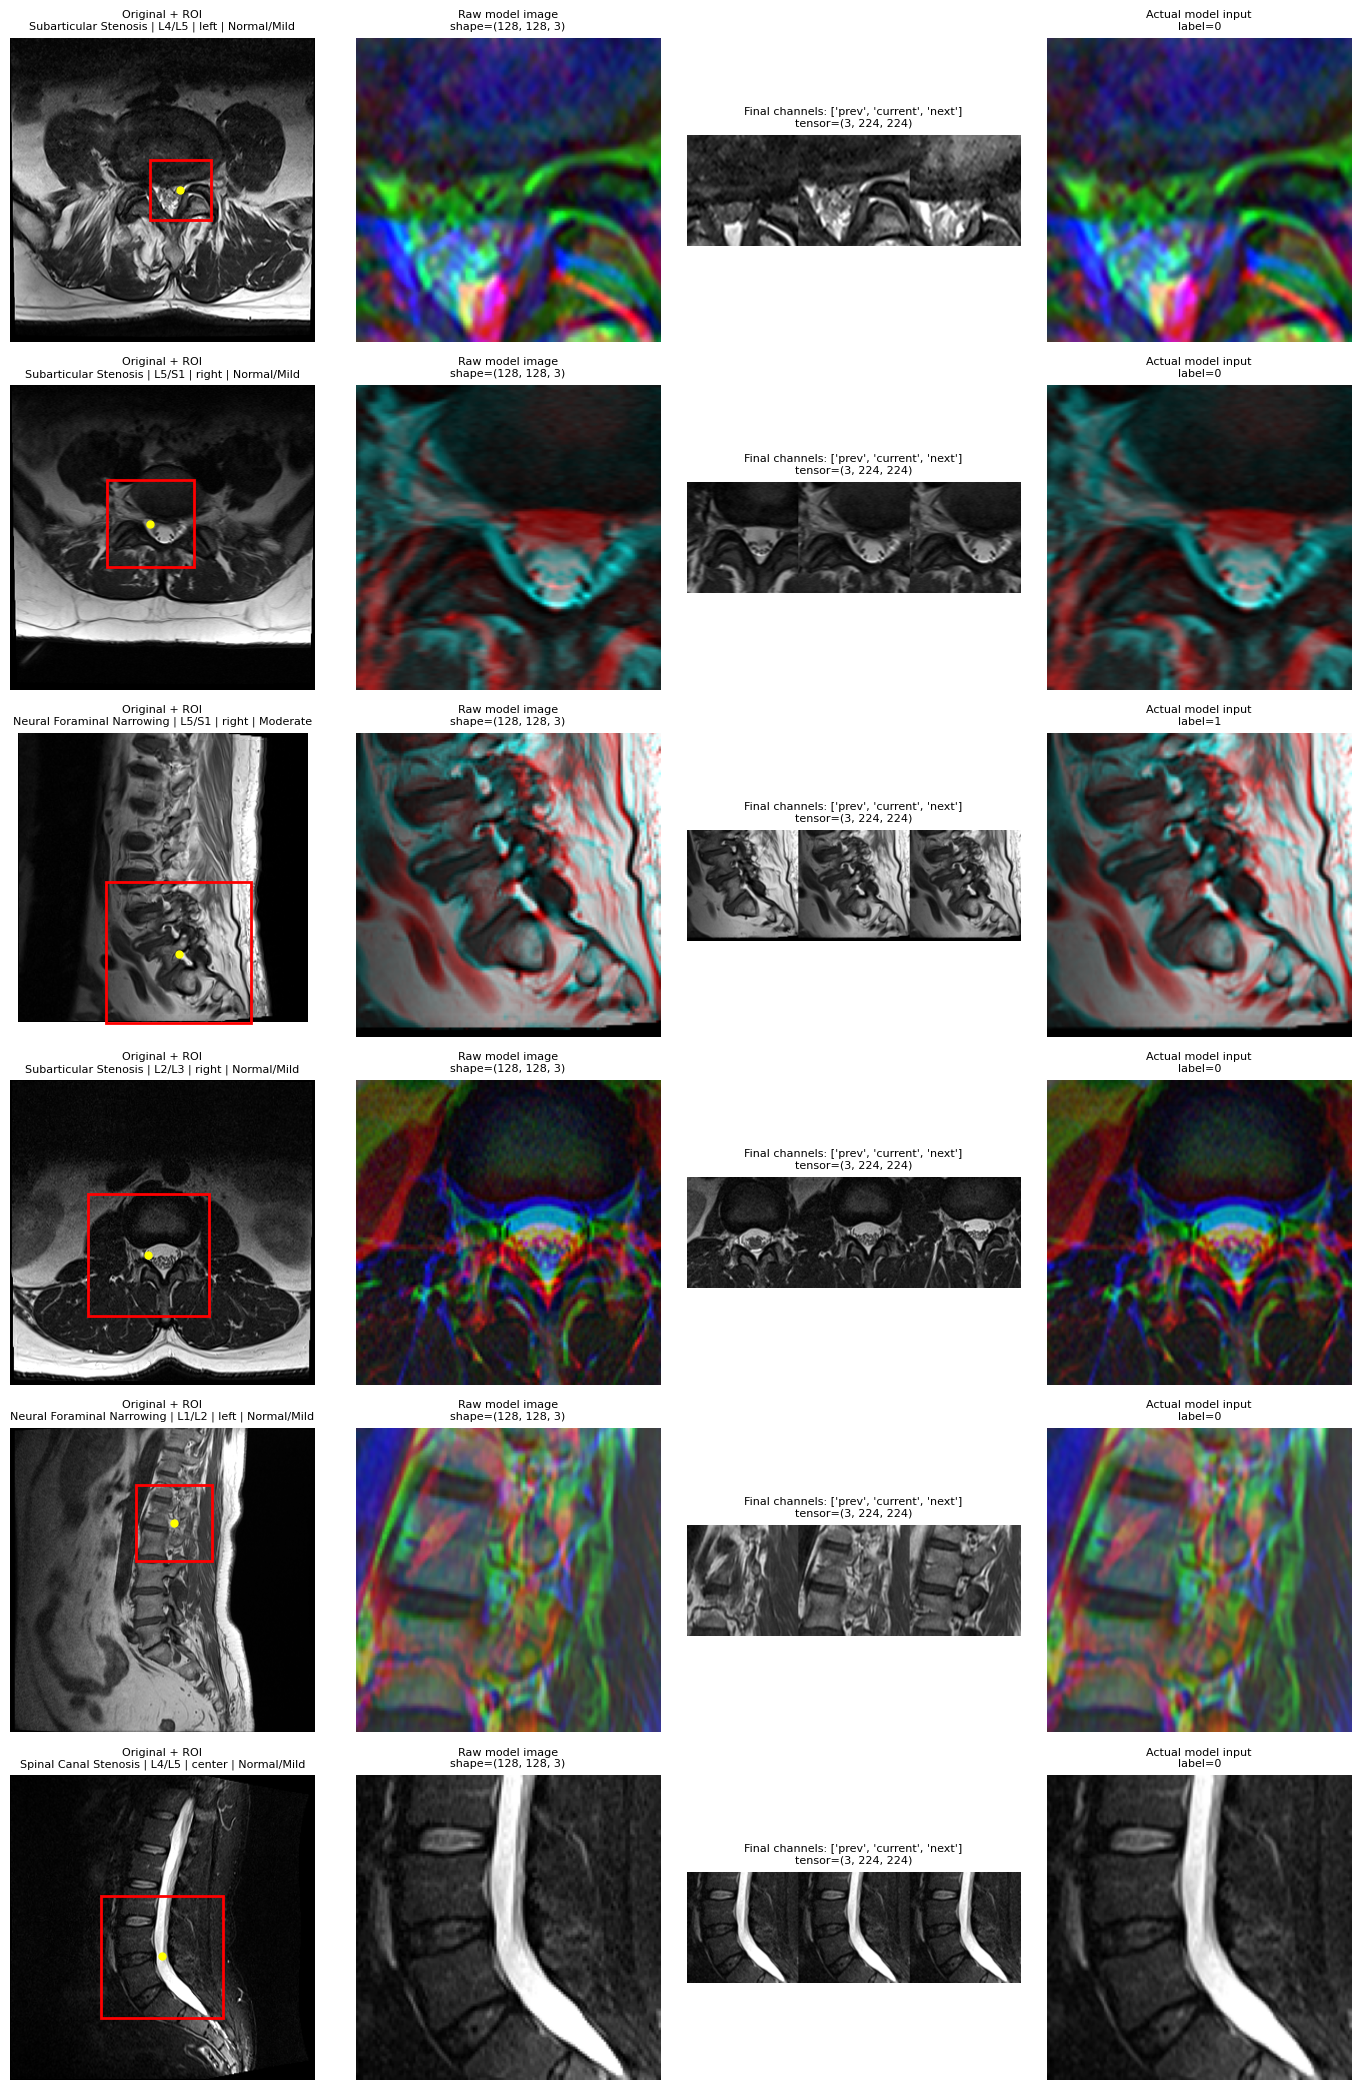

In [13]:
# ============================================================
# VISUAL SANITY CHECK — ACTUAL DATASET OUTPUT
# ============================================================
#
# This visualizes the same dataset pipeline used for training:
# DICOM -> optional ROI crop -> optional 2.5D neighbouring-slice channels
# -> resize -> tensor -> normalization.
#
# The displayed tensor is denormalized only for visualization.

def get_normalize_from_transform(transform):
    if isinstance(transform, transforms.Compose):
        for t in transform.transforms:
            if isinstance(t, transforms.Normalize):
                mean_t = torch.tensor(t.mean).view(3, 1, 1)
                std_t = torch.tensor(t.std).view(3, 1, 1)
                return mean_t, std_t

    return torch.zeros(3, 1, 1), torch.ones(3, 1, 1)


def tensor_to_display_image(image_tensor, transform):
    image_tensor = image_tensor.detach().cpu()

    mean_t, std_t = get_normalize_from_transform(transform)
    image_tensor = image_tensor * std_t + mean_t
    image_tensor = torch.clamp(image_tensor, 0, 1)

    return image_tensor.permute(1, 2, 0).numpy()


def plot_dataset_input_samples(
    dataset,
    n_samples=6,
    random_state=42,
):
    n_samples = min(n_samples, len(dataset))

    rng = np.random.default_rng(random_state)
    sample_indices = rng.choice(len(dataset), size=n_samples, replace=False)

    fig, axes = plt.subplots(
        n_samples,
        4,
        figsize=(14, 3.5 * n_samples),
    )

    if n_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, idx in enumerate(sample_indices):
        row = dataset.df.iloc[idx]

        # 1) Original image with ROI box.
        original_img, box = get_roi_box_for_display(row)

        ax = axes[row_idx, 0]
        ax.imshow(original_img, cmap="gray")
        ax.axis("off")
        ax.set_title(
            f"Original + ROI\n"
            f"{row['base_condition']} | {row['level']} | {row['side']} | {row['severity']}",
            fontsize=8,
        )

        if box is not None:
            x1, y1, x2, y2 = box
            ax.add_patch(
                plt.Rectangle(
                    (x1, y1),
                    x2 - x1,
                    y2 - y1,
                    fill=False,
                    linewidth=2,
                    edgecolor="red",
                )
            )

            if (
                X_COLUMN is not None
                and Y_COLUMN is not None
                and pd.notna(row[X_COLUMN])
                and pd.notna(row[Y_COLUMN])
            ):
                ax.scatter([row[X_COLUMN]], [row[Y_COLUMN]], s=25, c="yellow")

        # 2) Raw model PIL image before resize/tensor/normalization.
        #    For 2.5D, this is an RGB image where channels are neighbouring slices.
        raw_model_pil = dataset._load_model_image(row)
        raw_model_np = np.asarray(raw_model_pil)

        ax = axes[row_idx, 1]
        ax.imshow(raw_model_np)
        ax.axis("off")
        ax.set_title(
            f"Raw model image\nshape={raw_model_np.shape}",
            fontsize=8,
        )

        # 3) Show the three input channels separately.
        image_tensor, metadata, label = dataset[idx]
        display_img = tensor_to_display_image(image_tensor, dataset.transform)

        channel_titles = (
            ["prev", "current", "next"]
            if USE_2_5D_INPUT
            else ["gray", "gray", "gray"]
        )

        channel_panel = np.concatenate(
            [display_img[:, :, c] for c in range(3)],
            axis=1,
        )

        ax = axes[row_idx, 2]
        ax.imshow(channel_panel, cmap="gray")
        ax.axis("off")
        ax.set_title(
            f"Final channels: {channel_titles}\n"
            f"tensor={tuple(image_tensor.shape)}",
            fontsize=8,
        )

        # 4) Actual model RGB tensor after denormalization for display.
        ax = axes[row_idx, 3]
        ax.imshow(display_img)
        ax.axis("off")
        ax.set_title(
            f"Actual model input\nlabel={int(label)}",
            fontsize=8,
        )

    plt.tight_layout()
    plt.show()


# Deterministic sanity dataset: same preprocessing, no random augmentation.
sanity_dataset = LumbarMetadataClassificationDataset(
    norm_train_df.reset_index(drop=True),
    transform=val_transform,
    augmentation_transform=None,
    augment=False,
    use_roi_crop=ROI_CROP_ENABLED,
    use_2_5d_input=USE_2_5D_INPUT,
)

plot_dataset_input_samples(
    sanity_dataset,
    n_samples=6,
    random_state=42,
)


## 11. Image + metadata ResNet34 model

The CNN extracts image features.  
Metadata embeddings for `level`, `side`, and `series_description` are concatenated with image features before classification.

In [14]:
class ResNet34MetadataClassifier(nn.Module):
    def __init__(
        self,
        n_levels=5,
        n_sides=3,
        n_series=3,
        n_classes=N_CLASSES,
        pretrained=True,
        level_emb_dim=8,
        side_emb_dim=4,
        series_emb_dim=4,
        hidden_dim=HIDDEN_DIM,
        dropout=DROPOUT,
    ):
        super().__init__()

        if pretrained:
            weights = models.ResNet34_Weights.IMAGENET1K_V1
        else:
            weights = None

        self.backbone = models.resnet34(weights=weights)

        image_feature_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        self.level_emb = nn.Embedding(n_levels, level_emb_dim)
        self.side_emb = nn.Embedding(n_sides, side_emb_dim)
        self.series_emb = nn.Embedding(n_series, series_emb_dim)

        metadata_dim = level_emb_dim + side_emb_dim + series_emb_dim
        input_dim = image_feature_dim + metadata_dim

        # LayerNorm is used instead of BatchNorm1d because the final training batch
        # can occasionally contain one sample. BatchNorm1d crashes with batch size 1.
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout / 2),

            nn.Linear(hidden_dim // 2, n_classes),
        )

    def forward(self, images, metadata):
        image_features = self.backbone(images)

        level_features = self.level_emb(metadata["level"])
        side_features = self.side_emb(metadata["side"])
        series_features = self.series_emb(metadata["series"])

        metadata_features = torch.cat(
            [level_features, side_features, series_features],
            dim=1,
        )

        features = torch.cat(
            [image_features, metadata_features],
            dim=1,
        )

        logits = self.classifier(features)
        return logits


def make_optimizer(model, lr=LR, backbone_lr_multiplier=BACKBONE_LR_MULTIPLIER, weight_decay=WEIGHT_DECAY):
    """Use a lower learning rate for the pretrained image backbone and a higher one for the new metadata/head layers."""
    head_params = (
        list(model.level_emb.parameters())
        + list(model.side_emb.parameters())
        + list(model.series_emb.parameters())
        + list(model.classifier.parameters())
    )

    return torch.optim.AdamW(
        [
            {"params": model.backbone.parameters(), "lr": lr * backbone_lr_multiplier},
            {"params": head_params, "lr": lr},
        ],
        weight_decay=weight_decay,
    )


## 12. Loss, loaders, training, and evaluation utilities

In [15]:
def move_metadata_to_device(metadata, device):
    return {
        key: value.to(device, non_blocking=True)
        for key, value in metadata.items()
    }


def make_class_weighted_loss(
    train_df,
    device,
    moderate_weight_multiplier=MODERATE_WEIGHT_MULTIPLIER,
    severe_weight_multiplier=SEVERE_WEIGHT_MULTIPLIER,
    label_smoothing=LABEL_SMOOTHING,
):
    """
    Weighted cross-entropy for three-class medical classification.

    Base class weights are computed from the training split. The moderate and severe
    classes receive mild extra multipliers because under-calling pathology is more
    costly than over-calling it, especially for severe cases.
    """
    counts = np.bincount(train_df["target"].values, minlength=N_CLASSES).astype(np.float32)
    total = counts.sum()

    weights = np.zeros(N_CLASSES, dtype=np.float32)
    for cls in range(N_CLASSES):
        if counts[cls] > 0:
            weights[cls] = total / (N_CLASSES * counts[cls])
        else:
            weights[cls] = 0.0

    # Medical-priority adjustment:
    # class 0 = Normal/Mild, class 1 = Moderate, class 2 = Severe.
    if N_CLASSES > 1:
        weights[1] *= moderate_weight_multiplier
    if N_CLASSES > 2:
        weights[2] *= severe_weight_multiplier

    print("Class counts:", dict(zip(TARGET_NAMES, counts.astype(int))))
    print("Class weights:", dict(zip(TARGET_NAMES, weights.round(4))))

    weights = torch.tensor(weights, dtype=torch.float32).to(device)
    return nn.CrossEntropyLoss(weight=weights, label_smoothing=label_smoothing)


def make_weighted_sampler(train_df):
    """Optionally oversample minority-class examples during training batches."""
    targets = train_df["target"].values
    class_counts = np.bincount(targets, minlength=N_CLASSES).astype(np.float32)

    class_weights = np.zeros(N_CLASSES, dtype=np.float32)
    for cls in range(N_CLASSES):
        if class_counts[cls] > 0:
            class_weights[cls] = 1.0 / class_counts[cls]

    sample_weights = class_weights[targets]

    return WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
    )


def make_loaders(
    train_part,
    val_part,
    batch_size=BATCH_SIZE,
    use_weighted_sampler=USE_WEIGHTED_SAMPLER,
):
    train_dataset = LumbarMetadataClassificationDataset(
        train_part,
        transform=train_transform,
        augmentation_transform=train_augmentation,
        augment=USE_DATA_AUGMENTATION,
        use_roi_crop=ROI_CROP_ENABLED,
        use_2_5d_input=USE_2_5D_INPUT,
    )

    val_dataset = LumbarMetadataClassificationDataset(
        val_part,
        transform=val_transform,
        augment=False,
        use_roi_crop=ROI_CROP_ENABLED,
        use_2_5d_input=USE_2_5D_INPUT,
    )

    if use_weighted_sampler:
        train_sampler = make_weighted_sampler(train_part)
        shuffle_train = False
    else:
        train_sampler = None
        shuffle_train = True

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=shuffle_train,
        sampler=train_sampler,
        drop_last=True,  # avoids one-sample final batches and improves training stability
        **dataloader_worker_kwargs(NUM_WORKERS),
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        **dataloader_worker_kwargs(NUM_WORKERS),
    )

    return train_loader, val_loader


def make_test_loader(test_part, batch_size=BATCH_SIZE):
    test_dataset = LumbarMetadataClassificationDataset(
        test_part,
        transform=val_transform,
        augment=False,
        use_roi_crop=ROI_CROP_ENABLED,
        use_2_5d_input=USE_2_5D_INPUT,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        **dataloader_worker_kwargs(NUM_WORKERS),
    )

    return test_loader


In [16]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    n_seen = 0
    all_preds = []
    all_labels = []

    for images, metadata, labels in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        metadata = move_metadata_to_device(metadata, device)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images, metadata)
        loss = criterion(logits, labels)

        loss.backward()
        if GRAD_CLIP_NORM is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        n_seen += batch_size

        preds = logits.argmax(dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / max(n_seen, 1)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_bal_acc = balanced_accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return epoch_loss, epoch_acc, epoch_bal_acc, epoch_f1


@torch.no_grad()
def evaluate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    n_seen = 0
    all_preds = []
    all_labels = []
    all_probs = []

    for images, metadata, labels in tqdm(loader, leave=False):
        images = images.to(device, non_blocking=True)
        metadata = move_metadata_to_device(metadata, device)
        labels = labels.to(device, non_blocking=True)

        logits = model(images, metadata)
        loss = criterion(logits, labels)

        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        n_seen += batch_size

        all_probs.extend(probs.detach().cpu().numpy())
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    all_probs = np.asarray(all_probs)
    all_preds = np.asarray(all_preds)
    all_labels = np.asarray(all_labels)

    epoch_loss = running_loss / max(n_seen, 1)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_bal_acc = balanced_accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    severe_precision = precision_score(
        all_labels,
        all_preds,
        labels=[2],
        average="macro",
        zero_division=0,
    )

    severe_recall = recall_score(
        all_labels,
        all_preds,
        labels=[2],
        average="macro",
        zero_division=0,
    )

    severe_f1 = f1_score(
        all_labels,
        all_preds,
        labels=[2],
        average="macro",
        zero_division=0,
    )

    # Binary medical view: any pathological severity = Moderate or Severe.
    y_true_pathological = (all_labels >= 1).astype(int)
    y_pred_pathological = (all_preds >= 1).astype(int)

    pathological_precision = precision_score(
        y_true_pathological,
        y_pred_pathological,
        zero_division=0,
    )

    pathological_recall = recall_score(
        y_true_pathological,
        y_pred_pathological,
        zero_division=0,
    )

    pathological_f1 = f1_score(
        y_true_pathological,
        y_pred_pathological,
        zero_division=0,
    )

    try:
        epoch_logloss = log_loss(all_labels, all_probs, labels=list(range(N_CLASSES)))
    except ValueError:
        epoch_logloss = np.nan

    return {
        "loss": epoch_loss,
        "accuracy": epoch_acc,
        "balanced_accuracy": epoch_bal_acc,
        "macro_f1": epoch_f1,
        "severe_precision": severe_precision,
        "severe_recall": severe_recall,
        "severe_f1": severe_f1,
        "pathological_precision": pathological_precision,
        "pathological_recall": pathological_recall,
        "pathological_f1": pathological_f1,
        "log_loss": epoch_logloss,
        "y_true": all_labels,
        "y_pred": all_preds,
        "y_prob": all_probs,
    }


In [17]:
def fit_model(
    model_name,
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    epochs=EPOCHS,
    min_epochs=MIN_EPOCHS,
    patience=PATIENCE,
    min_delta=MIN_DELTA,
):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_checkpoint_score = -np.inf
    best_early_stop_score = -np.inf
    best_epoch = 0
    epochs_without_early_stop_improvement = 0

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "train_balanced_accuracy": [],
        "train_macro_f1": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_balanced_accuracy": [],
        "val_macro_f1": [],
        "val_severe_precision": [],
        "val_severe_recall": [],
        "val_severe_f1": [],
        "val_pathological_precision": [],
        "val_pathological_recall": [],
        "val_pathological_f1": [],
        "val_log_loss": [],
        "val_checkpoint_score": [],
        "val_early_stop_score": [],
    }

    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")

        train_loss, train_acc, train_bal_acc, train_f1 = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device,
        )

        val_metrics = evaluate_one_epoch(
            model,
            val_loader,
            criterion,
            device,
        )

        if scheduler is not None:
            scheduler.step(val_metrics["loss"])

        # Checkpointing is medically oriented: it prioritizes severe recall,
        # but still rewards severe F1, macro F1 and balanced accuracy.
        checkpoint_score = (
            0.35 * val_metrics["severe_recall"]
            + 0.25 * val_metrics["severe_f1"]
            + 0.20 * val_metrics["macro_f1"]
            + 0.20 * val_metrics["balanced_accuracy"]
        )

        # Early stopping uses a more general validation-progress signal.
        # This avoids stopping only because severe recall temporarily decreased
        # while F1/balanced accuracy continue to improve.
        early_stop_score = (
            0.50 * val_metrics["macro_f1"]
            + 0.50 * val_metrics["balanced_accuracy"]
        )

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_acc)
        history["train_balanced_accuracy"].append(train_bal_acc)
        history["train_macro_f1"].append(train_f1)

        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["val_balanced_accuracy"].append(val_metrics["balanced_accuracy"])
        history["val_macro_f1"].append(val_metrics["macro_f1"])
        history["val_severe_precision"].append(val_metrics["severe_precision"])
        history["val_severe_recall"].append(val_metrics["severe_recall"])
        history["val_severe_f1"].append(val_metrics["severe_f1"])
        history["val_pathological_precision"].append(val_metrics["pathological_precision"])
        history["val_pathological_recall"].append(val_metrics["pathological_recall"])
        history["val_pathological_f1"].append(val_metrics["pathological_f1"])
        history["val_log_loss"].append(val_metrics["log_loss"])
        history["val_checkpoint_score"].append(checkpoint_score)
        history["val_early_stop_score"].append(early_stop_score)

        print(
            f"Train loss: {train_loss:.4f} | "
            f"Train acc: {train_acc:.4f} | "
            f"Train bal acc: {train_bal_acc:.4f} | "
            f"Train macro F1: {train_f1:.4f}"
        )

        print(
            f"Val loss: {val_metrics['loss']:.4f} | "
            f"Val acc: {val_metrics['accuracy']:.4f} | "
            f"Val bal acc: {val_metrics['balanced_accuracy']:.4f} | "
            f"Val macro F1: {val_metrics['macro_f1']:.4f} | "
            f"Val severe precision: {val_metrics['severe_precision']:.4f} | "
            f"Val severe recall: {val_metrics['severe_recall']:.4f} | "
            f"Val severe F1: {val_metrics['severe_f1']:.4f} | "
            f"Checkpoint score: {checkpoint_score:.4f} | "
            f"Early-stop score: {early_stop_score:.4f}"
        )

        checkpoint_improved = checkpoint_score > best_checkpoint_score + min_delta
        early_stop_improved = early_stop_score > best_early_stop_score + min_delta

        if checkpoint_improved:
            best_checkpoint_score = checkpoint_score
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

            save_path = OUTPUT_DIR / f"{model_name}_best.pt"
            torch.save(best_model_wts, save_path)
            print(f"Saved best model: {save_path}")

        if early_stop_improved:
            best_early_stop_score = early_stop_score
            epochs_without_early_stop_improvement = 0
        else:
            epochs_without_early_stop_improvement += 1
            print(
                f"No early-stopping improvement for "
                f"{epochs_without_early_stop_improvement}/{patience} epochs."
            )

        if (epoch + 1) >= min_epochs and epochs_without_early_stop_improvement >= patience:
            print(
                f"Early stopping at epoch {epoch + 1}. "
                f"Best checkpoint epoch was {best_epoch} with checkpoint score {best_checkpoint_score:.4f}."
            )
            break

    model.load_state_dict(best_model_wts)

    history_df = pd.DataFrame(history)
    history_df.insert(0, "epoch", range(1, len(history_df) + 1))
    history_df.to_csv(OUTPUT_DIR / f"{model_name}_history.csv", index=False)

    return model, history_df


## 13. Plot helpers

In [18]:
# ============================================================
# EVALUATION HELPERS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score,
)
from sklearn.preprocessing import label_binarize


def plot_history(history_df, title="Training history"):
    epochs = history_df["epoch"]

    plt.figure(figsize=(20, 4))

    plt.subplot(1, 4, 1)
    plt.plot(epochs, history_df["train_loss"], label="train")
    plt.plot(epochs, history_df["val_loss"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 4, 2)
    plt.plot(epochs, history_df["train_balanced_accuracy"], label="train")
    plt.plot(epochs, history_df["val_balanced_accuracy"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Balanced accuracy")
    plt.title("Balanced accuracy")
    plt.legend()

    plt.subplot(1, 4, 3)
    plt.plot(epochs, history_df["train_macro_f1"], label="train")
    plt.plot(epochs, history_df["val_macro_f1"], label="val")
    plt.xlabel("Epoch")
    plt.ylabel("Macro F1")
    plt.title("Macro F1")
    plt.legend()

    plt.subplot(1, 4, 4)
    plt.plot(epochs, history_df["val_severe_recall"], label="severe recall")
    plt.plot(epochs, history_df["val_severe_precision"], label="severe precision")
    plt.plot(epochs, history_df["val_pathological_recall"], label="moderate/severe recall")
    plt.plot(epochs, history_df["val_checkpoint_score"], label="checkpoint score")
    plt.plot(epochs, history_df["val_early_stop_score"], label="early-stop score")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title("Medical-priority metrics")
    plt.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def load_best_model(model_name):
    model = ResNet34MetadataClassifier(
        n_levels=len(LEVEL_TO_ID),
        n_sides=len(SIDE_TO_ID),
        n_series=len(SERIES_TO_ID),
        n_classes=N_CLASSES,
        pretrained=PRETRAINED,
        hidden_dim=HIDDEN_DIM,
        dropout=DROPOUT,
    ).to(DEVICE)

    model_path = OUTPUT_DIR / f"{model_name}_best.pt"
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    return model


def compute_ovr_auc_and_accuracy(y_true, y_prob, class_names):
    """
    Computes class-wise one-vs-rest AUC and one-vs-rest accuracy.

    acc_ovr for a class means:
    class vs all other classes accuracy = (TP + TN) / all samples
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    n_classes = len(class_names)
    labels = list(range(n_classes))
    y_true_bin = label_binarize(y_true, classes=labels)

    auc_by_class = {}
    acc_ovr_by_class = {}

    for class_idx, class_name in enumerate(class_names):
        y_true_class = y_true_bin[:, class_idx]
        y_prob_class = y_prob[:, class_idx]

        # One-vs-rest prediction from predicted class probabilities
        y_pred_class = (np.argmax(y_prob, axis=1) == class_idx).astype(int)

        acc_ovr_by_class[class_name] = (y_true_class == y_pred_class).mean()

        if len(np.unique(y_true_class)) < 2:
            auc_by_class[class_name] = np.nan
        else:
            fpr, tpr, _ = roc_curve(y_true_class, y_prob_class)
            auc_by_class[class_name] = auc(fpr, tpr)

    try:
        macro_auc = roc_auc_score(
            y_true_bin,
            y_prob,
            average="macro",
            multi_class="ovr",
        )
    except ValueError:
        macro_auc = np.nan

    try:
        weighted_auc = roc_auc_score(
            y_true_bin,
            y_prob,
            average="weighted",
            multi_class="ovr",
        )
    except ValueError:
        weighted_auc = np.nan

    return auc_by_class, acc_ovr_by_class, macro_auc, weighted_auc


def make_report_table(y_true, y_pred, y_prob, class_names=TARGET_NAMES):
    labels = list(range(len(class_names)))

    report_dict = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=class_names,
        zero_division=0,
        output_dict=True,
    )

    report_table = pd.DataFrame(report_dict).T.reset_index()
    report_table = report_table.rename(columns={"index": "class"})

    auc_by_class, acc_ovr_by_class, macro_auc, weighted_auc = compute_ovr_auc_and_accuracy(
        y_true,
        y_prob,
        class_names,
    )

    report_table["acc_ovr"] = np.nan
    report_table["auc_ovr"] = np.nan

    for class_name in class_names:
        report_table.loc[report_table["class"] == class_name, "acc_ovr"] = acc_ovr_by_class[class_name]
        report_table.loc[report_table["class"] == class_name, "auc_ovr"] = auc_by_class[class_name]

    return report_table, macro_auc, weighted_auc


def plot_confusion_and_roc_side_by_side(
    y_true,
    y_pred,
    y_prob,
    class_names=TARGET_NAMES,
    title_prefix="Test",
    save_path=None,
):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_prob = np.asarray(y_prob)

    n_classes = len(class_names)
    labels = list(range(n_classes))

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    y_true_bin = label_binarize(y_true, classes=labels)

    auc_by_class, _, macro_auc, weighted_auc = compute_ovr_auc_and_accuracy(
        y_true,
        y_prob,
        class_names,
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ----------------------------
    # Confusion matrix
    # ----------------------------
    ax = axes[0]
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.set_title(f"{title_prefix}\nConfusion matrix")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    tick_marks = np.arange(n_classes)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(class_names)

    thresh = cm.max() / 2 if cm.max() > 0 else 0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j,
                i,
                format(cm[i, j], "d"),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black",
            )

    ax.set_ylabel("True label")
    ax.set_xlabel("Predicted label")

    # ----------------------------
    # ROC curves
    # ----------------------------
    ax = axes[1]

    for class_idx, class_name in enumerate(class_names):
        y_true_class = y_true_bin[:, class_idx]
        y_prob_class = y_prob[:, class_idx]

        if len(np.unique(y_true_class)) < 2:
            continue

        fpr, tpr, _ = roc_curve(y_true_class, y_prob_class)

        ax.plot(
            fpr,
            tpr,
            linewidth=2,
            label=f"{class_name} AUC={auc_by_class[class_name]:.3f}",
        )

    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Chance")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(
        f"{title_prefix}\nROC / AUC | Macro={macro_auc:.3f}, Weighted={weighted_auc:.3f}"
    )
    ax.legend(loc="lower right")
    ax.grid(alpha=0.3)

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

    return macro_auc, weighted_auc

## 14. Train the three classifiers

This trains:

- `spinal_canal_stenosis`
- `neural_foraminal_narrowing`
- `subarticular_stenosis`


Training model: spinal_canal_stenosis
Class counts: {'Normal/Mild': np.int64(5964), 'Moderate': np.int64(513), 'Severe': np.int64(343)}
Class weights: {'Normal/Mild': np.float32(0.3812), 'Moderate': np.float32(4.8746), 'Severe': np.float32(8.6161)}

Epoch 1/50


  0%|          | 0/213 [00:00<?, ?it/s]

  0%|          | 0/46 [00:00<?, ?it/s]

Train loss: 0.8750 | Train acc: 0.6916 | Train bal acc: 0.5527 | Train macro F1: 0.4475
Val loss: 0.6615 | Val acc: 0.8311 | Val bal acc: 0.6850 | Val macro F1: 0.5994 | Val severe precision: 0.4343 | Val severe recall: 0.6825 | Val severe F1: 0.5309 | Checkpoint score: 0.6285 | Early-stop score: 0.6422
Saved best model: models/models_baseline_three_class_medical_oriented_roi_crop_2p5d/spinal_canal_stenosis_best.pt

Epoch 2/50


  0%|          | 0/213 [00:00<?, ?it/s]

...

  0%|          | 0/46 [00:00<?, ?it/s]

Train loss: 0.0823 | Train acc: 0.9839 | Train bal acc: 0.9705 | Train macro F1: 0.9565
Val loss: 1.6405 | Val acc: 0.9036 | Val bal acc: 0.6691 | Val macro F1: 0.6598 | Val severe precision: 0.5493 | Val severe recall: 0.6190 | Val severe F1: 0.5821 | Checkpoint score: 0.6280 | Early-stop score: 0.6645
No early-stopping improvement for 9/10 epochs.

Epoch 18/50


  0%|          | 0/213 [00:00<?, ?it/s]

  0%|          | 0/46 [00:00<?, ?it/s]

Train loss: 0.0624 | Train acc: 0.9846 | Train bal acc: 0.9761 | Train macro F1: 0.9585
Val loss: 1.7635 | Val acc: 0.9022 | Val bal acc: 0.6554 | Val macro F1: 0.6461 | Val severe precision: 0.5395 | Val severe recall: 0.6508 | Val severe F1: 0.5899 | Checkpoint score: 0.6356 | Early-stop score: 0.6507
No early-stopping improvement for 10/10 epochs.
Early stopping at epoch 18. Best checkpoint epoch was 2 with checkpoint score 0.7064.


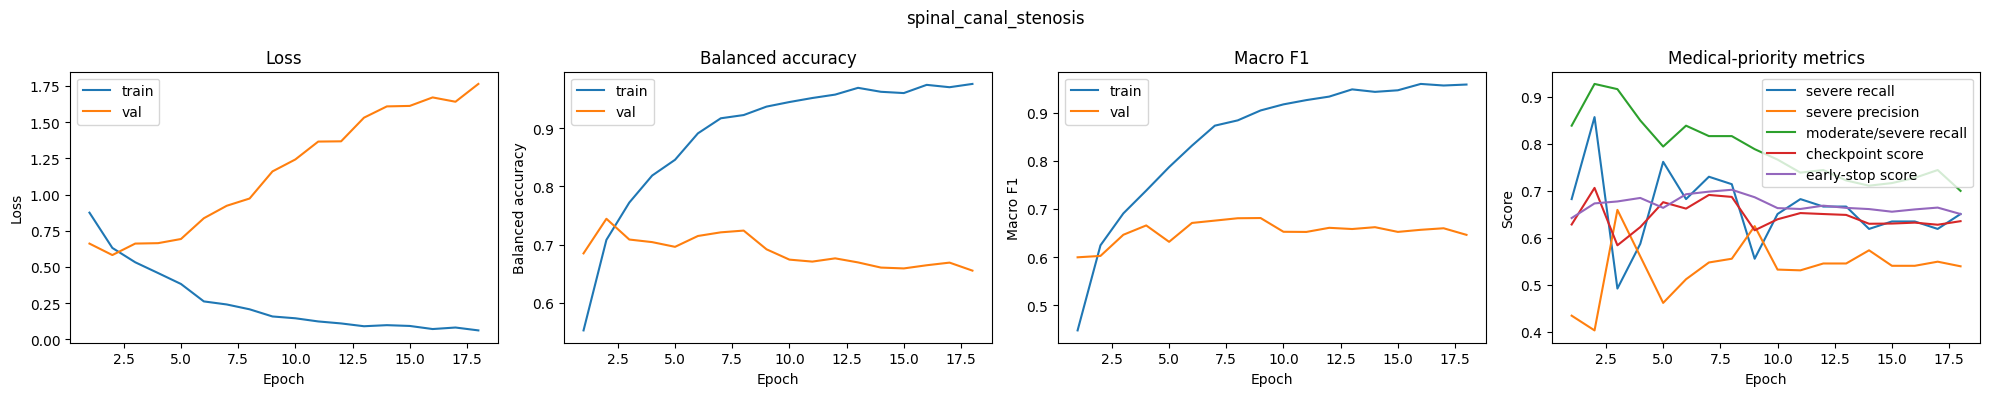


Training model: neural_foraminal_narrowing
Class counts: {'Normal/Mild': np.int64(10800), 'Moderate': np.int64(2462), 'Severe': np.int64(517)}
Class weights: {'Normal/Mild': np.float32(0.4253), 'Moderate': np.float32(2.0521), 'Severe': np.float32(11.5491)}

Epoch 1/50


  0%|          | 0/430 [00:00<?, ?it/s]

  0%|          | 0/93 [00:00<?, ?it/s]

Train loss: 0.9136 | Train acc: 0.6521 | Train bal acc: 0.5298 | Train macro F1: 0.4596
Val loss: 0.7928 | Val acc: 0.7293 | Val bal acc: 0.6093 | Val macro F1: 0.5635 | Val severe precision: 0.3333 | Val severe recall: 0.4526 | Val severe F1: 0.3839 | Checkpoint score: 0.4889 | Early-stop score: 0.5864
Saved best model: models/models_baseline_three_class_medical_oriented_roi_crop_2p5d/neural_foraminal_narrowing_best.pt

Epoch 2/50


  0%|          | 0/430 [00:00<?, ?it/s]

...

  0%|          | 0/93 [00:00<?, ?it/s]

Train loss: 0.1139 | Train acc: 0.9617 | Train bal acc: 0.9589 | Train macro F1: 0.9477
Val loss: 2.2327 | Val acc: 0.8159 | Val bal acc: 0.6159 | Val macro F1: 0.6326 | Val severe precision: 0.5575 | Val severe recall: 0.4599 | Val severe F1: 0.5040 | Checkpoint score: 0.5366 | Early-stop score: 0.6242
No early-stopping improvement for 9/10 epochs.

Epoch 23/50


  0%|          | 0/430 [00:00<?, ?it/s]

  0%|          | 0/93 [00:00<?, ?it/s]

Train loss: 0.0975 | Train acc: 0.9657 | Train bal acc: 0.9665 | Train macro F1: 0.9553
Val loss: 2.2296 | Val acc: 0.8142 | Val bal acc: 0.6179 | Val macro F1: 0.6349 | Val severe precision: 0.5714 | Val severe recall: 0.4672 | Val severe F1: 0.5141 | Checkpoint score: 0.5426 | Early-stop score: 0.6264
No early-stopping improvement for 10/10 epochs.
Early stopping at epoch 23. Best checkpoint epoch was 4 with checkpoint score 0.6409.


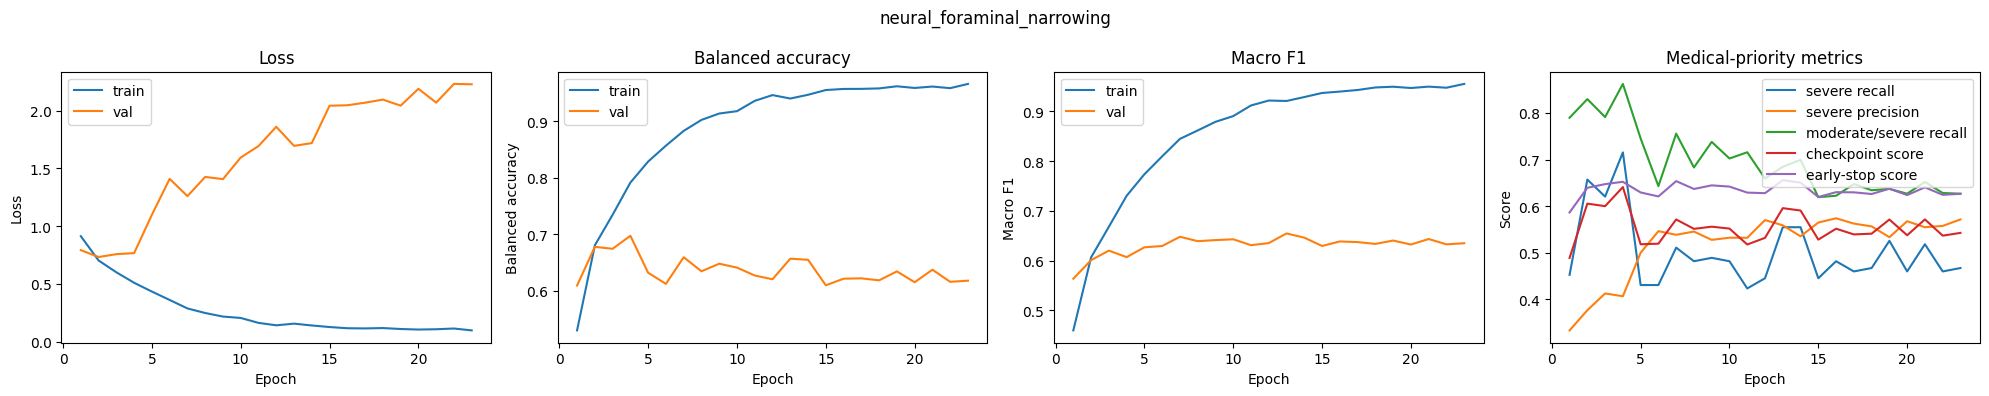


Training model: subarticular_stenosis
Class counts: {'Normal/Mild': np.int64(9601), 'Moderate': np.int64(2549), 'Severe': np.int64(1291)}
Class weights: {'Normal/Mild': np.float32(0.4667), 'Moderate': np.float32(1.9335), 'Severe': np.float32(4.5116)}

Epoch 1/50


  0%|          | 0/420 [00:00<?, ?it/s]

  0%|          | 0/90 [00:00<?, ?it/s]

Train loss: 0.8389 | Train acc: 0.6321 | Train bal acc: 0.5855 | Train macro F1: 0.5143
Val loss: 0.8002 | Val acc: 0.7580 | Val bal acc: 0.6370 | Val macro F1: 0.6256 | Val severe precision: 0.5356 | Val severe recall: 0.6314 | Val severe F1: 0.5796 | Checkpoint score: 0.6184 | Early-stop score: 0.6313
Saved best model: models/models_baseline_three_class_medical_oriented_roi_crop_2p5d/subarticular_stenosis_best.pt

Epoch 2/50


  0%|          | 0/420 [00:00<?, ?it/s]

...

  0%|          | 0/90 [00:00<?, ?it/s]

Train loss: 0.1702 | Train acc: 0.9231 | Train bal acc: 0.9335 | Train macro F1: 0.9094
Val loss: 1.4952 | Val acc: 0.7584 | Val bal acc: 0.6569 | Val macro F1: 0.6511 | Val severe precision: 0.6234 | Val severe recall: 0.5438 | Val severe F1: 0.5809 | Checkpoint score: 0.5972 | Early-stop score: 0.6540
No early-stopping improvement for 11/10 epochs.

Epoch 15/50


  0%|          | 0/420 [00:00<?, ?it/s]

  0%|          | 0/90 [00:00<?, ?it/s]

Train loss: 0.1616 | Train acc: 0.9283 | Train bal acc: 0.9361 | Train macro F1: 0.9148
Val loss: 1.6065 | Val acc: 0.7723 | Val bal acc: 0.6435 | Val macro F1: 0.6475 | Val severe precision: 0.6128 | Val severe recall: 0.5255 | Val severe F1: 0.5658 | Checkpoint score: 0.5836 | Early-stop score: 0.6455
No early-stopping improvement for 12/10 epochs.
Early stopping at epoch 15. Best checkpoint epoch was 2 with checkpoint score 0.6697.


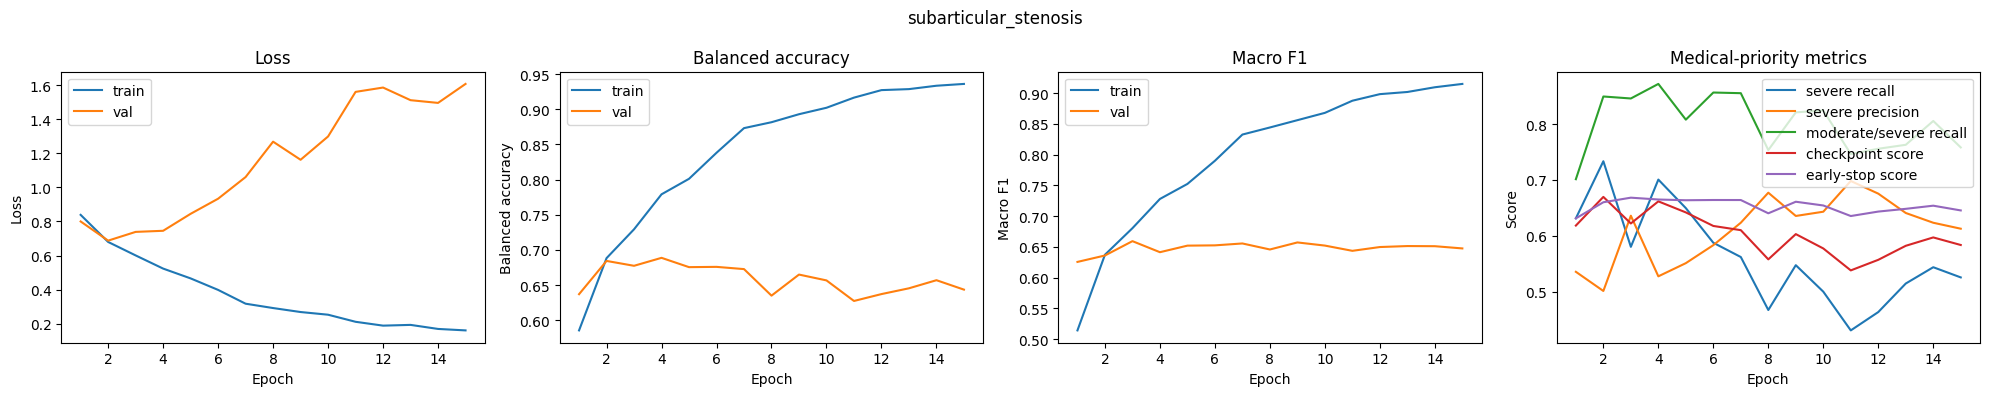

In [19]:
import gc

trained_models = {}
histories = {}

for model_name in MODEL_CONFIGS.keys():
    print("\n" + "=" * 80)
    print(f"Training model: {model_name}")
    print("=" * 80)

    # Explicitly release old loaders before creating new ones.
    try:
        del train_loader
        del val_loader
    except NameError:
        pass
    gc.collect()

    train_part = model_dfs[model_name]["train"]
    val_part = model_dfs[model_name]["val"]

    if len(train_part) == 0 or len(val_part) == 0:
        print(f"Skipping {model_name}: empty train or validation set.")
        continue

    train_loader, val_loader = make_loaders(
        train_part,
        val_part,
        batch_size=BATCH_SIZE,
        use_weighted_sampler=USE_WEIGHTED_SAMPLER,
    )

    model = ResNet34MetadataClassifier(
        n_levels=len(LEVEL_TO_ID),
        n_sides=len(SIDE_TO_ID),
        n_series=len(SERIES_TO_ID),
        n_classes=N_CLASSES,
        pretrained=PRETRAINED,
        hidden_dim=HIDDEN_DIM,
        dropout=DROPOUT,
    ).to(DEVICE)

    criterion = make_class_weighted_loss(train_part, DEVICE)
    optimizer = make_optimizer(model)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
    )

    model, history_df = fit_model(
        model_name=model_name,
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=DEVICE,
        epochs=EPOCHS,
        min_epochs=MIN_EPOCHS,
        patience=PATIENCE,
        min_delta=MIN_DELTA,
    )

    trained_models[model_name] = model
    histories[model_name] = history_df

    plot_history(history_df, title=model_name)


## 15. Test evaluation


Testing model: spinal_canal_stenosis
Class counts: {'Normal/Mild': np.int64(5964), 'Moderate': np.int64(513), 'Severe': np.int64(343)}
Class weights: {'Normal/Mild': np.float32(0.3812), 'Moderate': np.float32(4.8746), 'Severe': np.float32(8.6161)}


  0%|          | 0/46 [00:00<?, ?it/s]

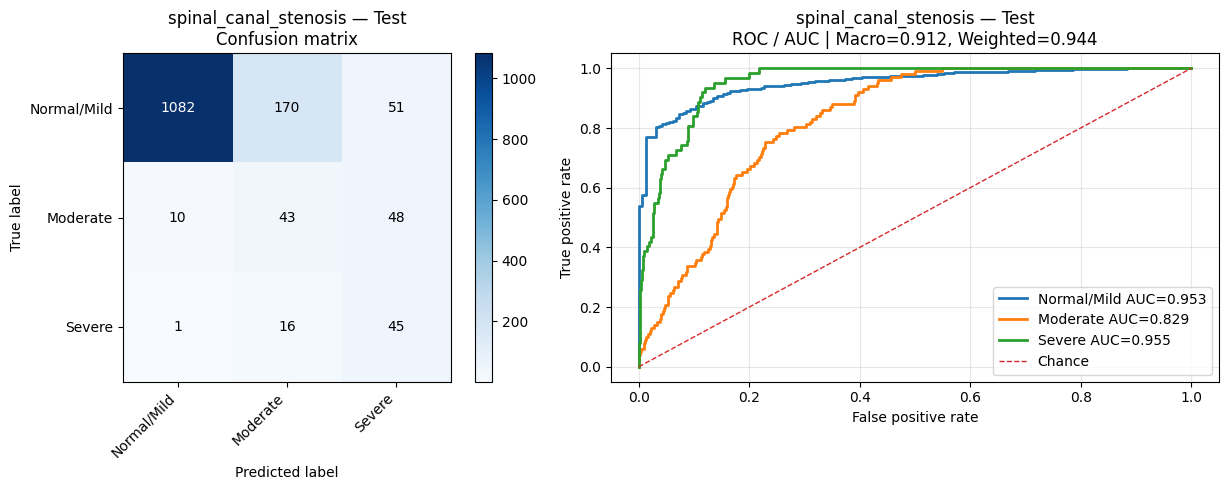

spinal_canal_stenosis — classification report


,class,precision,recall,f1-score,support,acc_ovr,auc_ovr
0,Normal/Mild,0.989936,0.830391,0.903172,1303.00000,0.841746,0.952573
1,Moderate,0.187773,0.425743,0.260606,101.00000,0.833561,0.828687
2,Severe,0.312500,0.725806,0.436893,62.00000,0.920873,0.954657
3,accuracy,0.798090,0.798090,0.798090,0.79809,NaN,NaN
4,macro avg,0.496736,0.660647,0.533557,1466.00000,NaN,NaN
5,weighted avg,0.906021,0.798090,0.839183,1466.00000,NaN,NaN



Testing model: neural_foraminal_narrowing
Class counts: {'Normal/Mild': np.int64(10800), 'Moderate': np.int64(2462), 'Severe': np.int64(517)}
Class weights: {'Normal/Mild': np.float32(0.4253), 'Moderate': np.float32(2.0521), 'Severe': np.float32(11.5491)}


  0%|          | 0/93 [00:00<?, ?it/s]

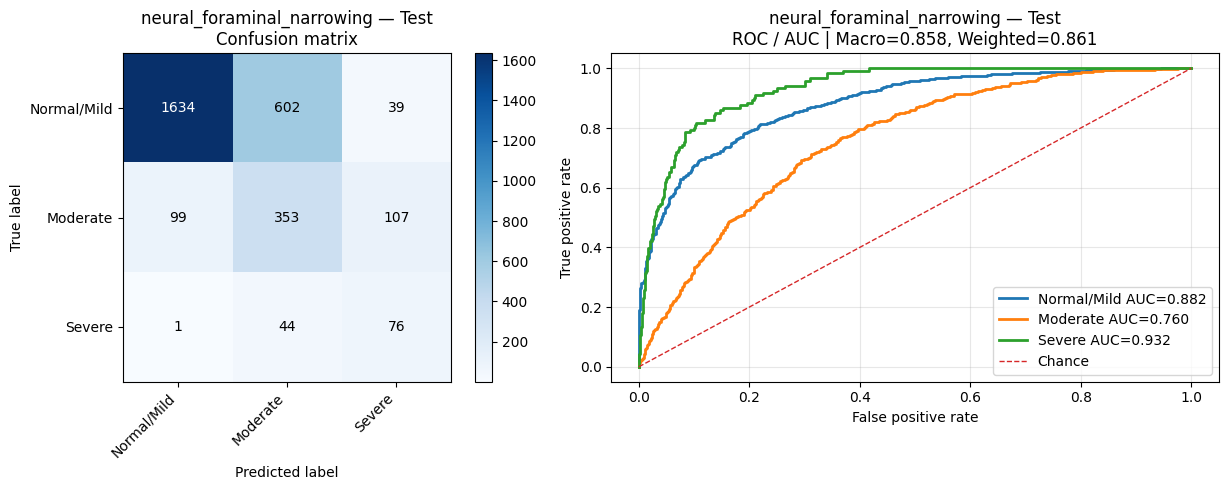

neural_foraminal_narrowing — classification report


,class,precision,recall,f1-score,support,acc_ovr,auc_ovr
0,Normal/Mild,0.942330,0.718242,0.815166,2275.000000,0.749239,0.882077
1,Moderate,0.353353,0.631485,0.453145,559.000000,0.711675,0.759743
2,Severe,0.342342,0.628099,0.443149,121.000000,0.935364,0.932257
3,accuracy,0.698139,0.698139,0.698139,0.698139,NaN,NaN
4,macro avg,0.546009,0.659275,0.570487,2955.000000,NaN,NaN
5,weighted avg,0.806345,0.698139,0.731449,2955.000000,NaN,NaN



Testing model: subarticular_stenosis
Class counts: {'Normal/Mild': np.int64(9601), 'Moderate': np.int64(2549), 'Severe': np.int64(1291)}
Class weights: {'Normal/Mild': np.float32(0.4667), 'Moderate': np.float32(1.9335), 'Severe': np.float32(4.5116)}


  0%|          | 0/91 [00:00<?, ?it/s]

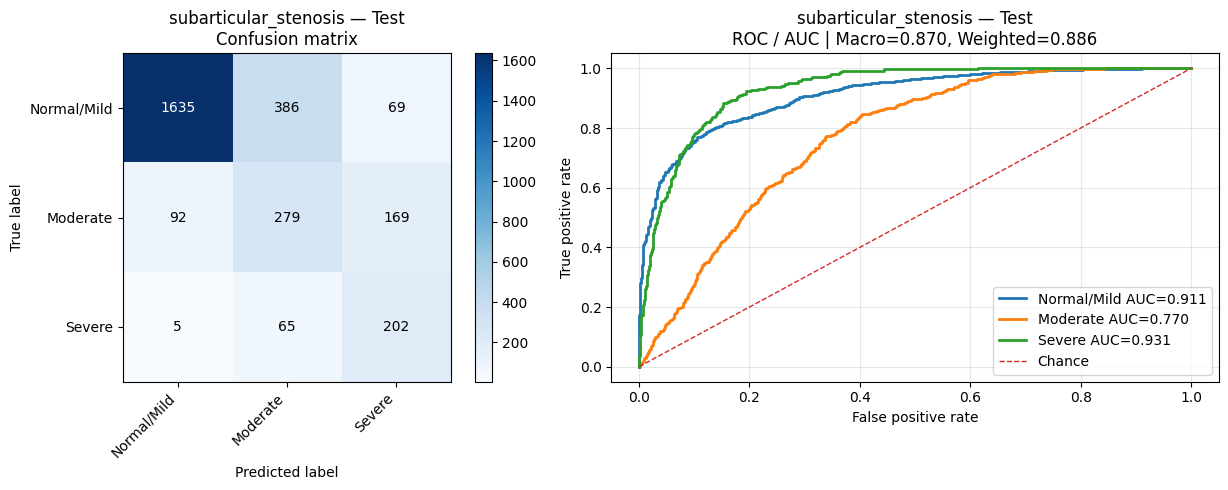

subarticular_stenosis — classification report


,class,precision,recall,f1-score,support,acc_ovr,auc_ovr
0,Normal/Mild,0.943995,0.782297,0.855573,2090.000000,0.809786,0.910616
1,Moderate,0.382192,0.516667,0.439370,540.000000,0.754652,0.769898
2,Severe,0.459091,0.742647,0.567416,272.000000,0.893866,0.930712
3,accuracy,0.729152,0.729152,0.729152,0.729152,NaN,NaN
4,macro avg,0.595093,0.680537,0.620786,2902.000000,NaN,NaN
5,weighted avg,0.794006,0.729152,0.751118,2902.000000,NaN,NaN


,model,input,pretrained,use_weighted_sampler,moderate_weight_multiplier,severe_weight_multiplier,label_smoothing,hidden_dim,dropout,backbone_lr_multiplier,...,test_pathological_recall,test_pathological_f1,n_test_rows,n_test_studies,test_acc_normal_mild_ovr,test_auc_normal_mild_ovr,test_acc_moderate_ovr,test_auc_moderate_ovr,test_acc_severe_ovr,test_auc_severe_ovr
0,spinal_canal_stenosis,full_image_grayscale_repeated_3ch_plus_metadata,True,False,1.1,1.3,0.0,512,0.15,0.1,...,0.932515,0.567164,1466,297,0.841746,0.952573,0.833561,0.828687,0.920873,0.954657
1,neural_foraminal_narrowing,full_image_grayscale_repeated_3ch_plus_metadata,True,False,1.1,1.3,0.0,512,0.15,0.1,...,0.852941,0.610205,2955,296,0.749239,0.882077,0.711675,0.759743,0.935364,0.932257
2,subarticular_stenosis,full_image_grayscale_repeated_3ch_plus_metadata,True,False,1.1,1.3,0.0,512,0.15,0.1,...,0.880542,0.721493,2902,297,0.809786,0.910616,0.754652,0.769898,0.893866,0.930712


Saved: models/models_baseline_three_class_medical_oriented_roi_crop_2p5d/test_results_medical_oriented_pretrained.csv


In [20]:
# ============================================================
# TEST EVALUATION
# ============================================================

test_results = []

for model_name in MODEL_CONFIGS.keys():
    print("\n" + "=" * 80)
    print(f"Testing model: {model_name}")
    print("=" * 80)

    test_part = model_dfs[model_name]["test"]

    if len(test_part) == 0:
        print(f"Skipping {model_name}: empty test set.")
        continue

    model = load_best_model(model_name)
    test_loader = make_test_loader(test_part, batch_size=BATCH_SIZE)

    # Use train split for loss weights; metrics are the primary comparison.
    criterion = make_class_weighted_loss(model_dfs[model_name]["train"], DEVICE)

    metrics = evaluate_one_epoch(
        model,
        test_loader,
        criterion,
        DEVICE,
    )

    # ------------------------------------------------------------
    # Combined plot: confusion matrix + ROC/AUC
    # ------------------------------------------------------------
    combined_plot_path = OUTPUT_DIR / f"{model_name}_test_confusion_and_roc.png"

    macro_auc, weighted_auc = plot_confusion_and_roc_side_by_side(
        metrics["y_true"],
        metrics["y_pred"],
        metrics["y_prob"],
        class_names=TARGET_NAMES,
        title_prefix=f"{model_name} — Test",
        save_path=combined_plot_path,
    )

    # ------------------------------------------------------------
    # One report table: precision, recall, f1, support, acc_ovr, auc_ovr
    # ------------------------------------------------------------
    report_table, macro_auc, weighted_auc = make_report_table(
        metrics["y_true"],
        metrics["y_pred"],
        metrics["y_prob"],
        class_names=TARGET_NAMES,
    )

    print(f"{model_name} — classification report")
    display(report_table)

    row = {
        "model": model_name,
        "input": "full_image_grayscale_repeated_3ch_plus_metadata",
        "pretrained": PRETRAINED,
        "use_weighted_sampler": USE_WEIGHTED_SAMPLER,
        "moderate_weight_multiplier": MODERATE_WEIGHT_MULTIPLIER,
        "severe_weight_multiplier": SEVERE_WEIGHT_MULTIPLIER,
        "label_smoothing": LABEL_SMOOTHING,
        "hidden_dim": HIDDEN_DIM,
        "dropout": DROPOUT,
        "backbone_lr_multiplier": BACKBONE_LR_MULTIPLIER,
        "min_epochs": MIN_EPOCHS,
        "patience": PATIENCE,
        "test_loss": metrics["loss"],
        "test_log_loss": metrics["log_loss"],
        "test_accuracy": metrics["accuracy"],
        "test_balanced_accuracy": metrics["balanced_accuracy"],
        "test_macro_f1": metrics["macro_f1"],
        "test_macro_auc_ovr": macro_auc,
        "test_weighted_auc_ovr": weighted_auc,
        "test_severe_precision": metrics["severe_precision"],
        "test_severe_recall": metrics["severe_recall"],
        "test_severe_f1": metrics["severe_f1"],
        "test_pathological_precision": metrics["pathological_precision"],
        "test_pathological_recall": metrics["pathological_recall"],
        "test_pathological_f1": metrics["pathological_f1"],
        "n_test_rows": len(test_part),
        "n_test_studies": test_part["study_id"].nunique(),
    }

    # Add class-wise AUC and one-vs-rest accuracy into the main results table.
    for _, report_row in report_table.iterrows():
        class_name = report_row["class"]

        if class_name not in TARGET_NAMES:
            continue

        safe_class_name = (
            class_name
            .lower()
            .replace("/", "_")
            .replace(" ", "_")
            .replace("-", "_")
        )

        row[f"test_acc_{safe_class_name}_ovr"] = report_row["acc_ovr"]
        row[f"test_auc_{safe_class_name}_ovr"] = report_row["auc_ovr"]

    test_results.append(row)

results_table = pd.DataFrame(test_results)
display(results_table)

suffix = "pretrained" if PRETRAINED else "scratch"
results_path = OUTPUT_DIR / f"test_results_medical_oriented_{suffix}.csv"

results_table.to_csv(results_path, index=False)

print("Saved:", results_path)